In [1]:
import sys
sys.path.append("../")

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import seaborn as sns
import scanpy as sc
import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "openpyxl")
from trajectory_inference.Laplacian_Eigenmaps import fullLaplacian, rankPseudo
from trajectory_inference.diffusion_maps import fullDiffusion
from data.preprocess.preprocess import revelio_like_preprocess, loadData, readMarkerSets
from data.preprocess.preprocess_faithful import revelio_faithful_preprocess

In [3]:
# loading in data and gene phase markers
countdf = loadData("../data/GSE142277/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt")
# countdf = loadData("../data/GSE142277/GSE142277_RAW/GSM4224316_out_gene_exon_tagged.dge_exonssf002_KO.txt")
# countdf = pd.concat([countdf,],axis=1)
marker_dict = readMarkerSets("../data/GSE142277/revelio_gene_sets.csv", format = "csv")

In [4]:
# processing data with revelio like processing function
adata = revelio_like_preprocess(countdf, marker_dict, 
                                min_genes_per_cell=1200,
                                min_phase_top_z=1)
# adata = revelio_faithful_preprocess(countdf,marker_dict)

G1.S 132 ['ABCA7', 'ACD', 'ACYP1', 'ADAMTS1', 'ADCK2', 'ADCY6', 'ANKRD10', 'AP4B1', 'APEX2', 'ARGLU1']
S 147 ['ABCC2', 'ABCC5', 'ABHD10', 'ACPP', 'ADAM22', 'ANKRD18A', 'ANKRD36', 'ARHGAP42', 'ASF1B', 'ATAD2']
G2 160 ['ALKBH1', 'ANLN', 'AP3D1', 'ARHGAP11B', 'ARHGAP19', 'ARL4A', 'ARMC1', 'ASXL1', 'ATL2', 'AURKB']
G2.M 186 ['AHI1', 'AKIRIN2', 'ANKRD40', 'ANLN', 'ANP32B', 'ANP32E', 'ARHGAP19', 'ARHGDIB', 'ARL6IP1', 'ASXL1']
M.G1 127 ['AFAP1', 'AGFG1', 'AGPAT3', 'AKAP13', 'AMD1', 'ANP32E', 'ANTXR1', 'BAG3', 'BTBD3', 'C3orf62']


In [5]:
le_emb,_,lpt = fullLaplacian(adata,k=5,nComponents=15)
dm_emb,_,_, dpt = fullDiffusion(adata,k=5,n_components=15,alpha=0.0)

In [6]:
adata.obsm['le_emb'] = le_emb
adata.obsm['dm_emb'] = dm_emb
adata.obs['lpt'] = lpt
adata.obs['dpt'] = dpt

In [7]:
adata

AnnData object with n_obs × n_vars = 671 × 1660
    obs: 'nUMI', 'nGene', 'cc_phase', 'best_val', 'second_val', 'phase_margin', 'lpt', 'dpt'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'phase_scores', 'phase_scores_z', 'X_pca', 'le_emb', 'dm_emb'
    varm: 'PCs'
    layers: 'log_of_fractions'

In [8]:
from revelio_pca_rotation import schwabe_style_optimal_rotation
import numpy as np

cc_pc_mask = np.zeros(adata.obsm['X_pca'][0].shape)
cc_pc_mask[:3] = 1

results = schwabe_style_optimal_rotation(adata.obsm['X_pca'], 
                               adata.obs['cc_phase'].values,
                               cc_pc_mask)

In [9]:
rotated = results['rotated_scores']
adata.obsm['rv_emb'] = rotated
adata.obs['rvpt'] = np.arctan2(rotated[:,0],rotated[:,1])+np.pi

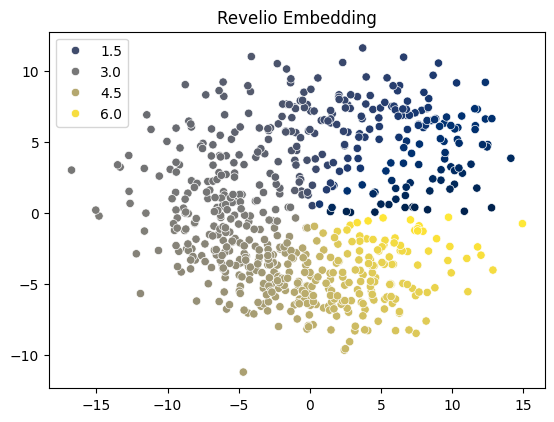

In [10]:
import seaborn as sns
rotated = results['rotated_scores']
fig,ax = plt.subplots()
rotated = rotated-rotated.mean(axis=0)
adata.obs['pseudotime'] = -np.arctan2(rotated[:,0],rotated[:,1])+np.pi
sns.scatterplot(x=rotated[:,0],y=rotated[:,1],hue=results['angle'],ax=ax,palette='cividis')
ax.set_title('Revelio Embedding')
ax.set_aspect('equal')

In [11]:
adata.obs['pseudotime'].describe()

count    671.000000
mean       3.277071
std        1.873854
min        0.002493
25%        1.707816
50%        3.313750
75%        4.944131
max        6.278030
Name: pseudotime, dtype: float64

In [12]:
adata.obs['cc_phase'] = adata.obs['cc_phase'].str.replace('.','/')
adata.obs['cc_phase'] = pd.Categorical(adata.obs['cc_phase'],categories=['G1/S','S','G2','G2/M','M/G1'],ordered=True)

In [13]:
PHASE_ORDER = ['G1/S','S','G2','G2/M','M/G1']
from scipy import stats
from ajay_circular_transformation import circ_mean as circular_mean

def unroll_pseudotime_for_plot(adata, pseudotime):
    """Linearize a circular pseudotime so each phase forms a single mode.

    Two transforms, both invariant w.r.t. the circular structure:
      (1) If S is "behind" G1/S on the circle (eigenvector-sign flip),
          reflect: pt → (2π - pt) % 2π. Restores G1/S → S → G2 → G2/M
          → M/G1 forward direction.
      (2) Find the largest gap between consecutive phase circular means
          and place the [0, 2π) seam in that gap. This guarantees no
          phase straddles the cut, so violins are unimodal.

    Returns the rotated/reflected pseudotime in [0, 2π).
    """
    pt = np.asarray(pseudotime).copy()
    phases = np.asarray(adata.obs["cc_phase"].values)

    def _means(p):
        m = {}
        for ph in PHASE_ORDER:
            mask = phases == ph
            if mask.sum() == 0:
                continue
            m[ph] = circular_mean(p[mask]) % (2 * np.pi)
        return m

    means = _means(pt)

    # (1) Forward direction: S should be just after G1/S on the circle.
    if "G1/S" in means and "S" in means:
        fwd_gap = (means["S"] - means["G1/S"]) % (2 * np.pi)
        if fwd_gap > np.pi:
            pt = (-pt) % (2 * np.pi)
            means = _means(pt)

    # (2) Cut the circle at the largest gap between phase means.
    sorted_means = np.sort(np.array(list(means.values())))
    gaps = np.diff(np.concatenate([sorted_means,
                                   sorted_means[:1] + 2 * np.pi]))
    cut = sorted_means[int(np.argmax(gaps))]
    pt = (pt - cut) % (2 * np.pi)
    return pt


def plot_pseudotime_violin(adata, pseudotime, save_path="pseudotime_violin.jpg",
                           title="Pseudotime distribution by phase",
                           unroll=True, ax=None, show_spearman=True):
    """Violin plot of pseudotime per cell-cycle phase.

    Pass ``ax`` to draw into an existing Axes (panel composition);
    otherwise the function creates its own figure. With ``show_spearman``
    (default True), each y-tick label gets the Spearman ρ between the
    pseudotime and that phase's z-score appended underneath. Returns
    (fig, ax).
    """
    pt = np.asarray(pseudotime).copy().astype(float)
    if unroll:
        pt = unroll_pseudotime_for_plot(adata, pt)
    phases = np.asarray(adata.obs["cc_phase"].values)

    # Per-phase circular alignment with PHASE_ORDER monotonicity:
    #   1. Compute each phase's circular mean.
    #   2. Lift each successive mean by k·2π so it's strictly greater
    #      than the previous phase's lifted mean. This forces violins
    #      onto the axis in canonical phase order regardless of where
    #      circular_mean lands (it can drift to the seam for bimodal
    #      phases like M/G1, which would otherwise dump M/G1 at the
    #      low end).
    #   3. Within each phase, shift cells to lie within ±π of that
    #      lifted target. Cells may end up <0 or >2π — that extends the
    #      linear axis so angular neighbors stay numerical neighbors.
    targets = {}
    prev = None
    for ph in PHASE_ORDER:
        ph_mask = phases == ph
        if ph_mask.sum() == 0:
            continue
        m = circular_mean(pt[ph_mask]) % (2 * np.pi)
        if prev is not None:
            while m <= prev:
                m += 2 * np.pi
        targets[ph] = m
        prev = m

    for ph, target in targets.items():
        ph_mask = phases == ph
        diffs = pt[ph_mask] - target
        aligned = (diffs + np.pi) % (2 * np.pi) - np.pi
        pt[ph_mask] = target + aligned

    mask = np.isin(phases, PHASE_ORDER)
    df = pd.DataFrame({"pseudotime": pt[mask], "phase": phases[mask]})

    cmap = plt.cm.get_cmap("cividis", len(PHASE_ORDER))
    palette = {ph: cmap(i) for i, ph in enumerate(PHASE_ORDER)}

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    else:
        fig = ax.figure
    sns.violinplot(data=df, x="pseudotime", y="phase", order=PHASE_ORDER,
                   palette=palette, inner="box", linewidth=1, ax=ax)

    # Span: from the earliest G1/S cell to the latest M/G1 cell — after
    # per-phase alignment this is the natural cycle range.
    g1s_vals = df.loc[df["phase"] == "G1/S", "pseudotime"]
    mg1_vals = df.loc[df["phase"] == "M/G1", "pseudotime"]
    # if len(g1s_vals) and len(mg1_vals):
    #     ax.set_xlim(float(g1s_vals.min()), float(mg1_vals.max()))

    # x-axis ticks in multiples of π/2.
    from matplotlib.ticker import FuncFormatter, MultipleLocator

    def _pi_formatter(x, _pos):
        n = x / np.pi
        if abs(n) < 1e-9:
            return "0"
        # 3π marks the cyclic wraparound back to G1/S → label as 0
        if abs(n - 3) < 1e-9:
            return "0"
        # whole multiples of π
        if abs(n - round(n)) < 1e-9:
            k = int(round(n))
            if k == 1:
                return "π"
            if k == -1:
                return "−π"
            return f"{k}π"
        # half multiples of π
        n2 = 2 * n
        if abs(n2 - round(n2)) < 1e-9:
            k = int(round(n2))
            if k == 1:
                return "π/2"
            if k == -1:
                return "−π/2"
            return f"{k}π/2"
        return f"{n:.2f}π"

    ax.xaxis.set_major_locator(MultipleLocator(np.pi))
    ax.xaxis.set_major_formatter(FuncFormatter(_pi_formatter))

    # Append per-phase Spearman ρ to the y-tick labels. Use the
    # transformed pt (post-unroll + per-phase alignment) so the numbers
    # match what's visible in the violins. Note: phases whose density
    # peaks in the middle of the axis will get small |ρ| even when the
    # localization is good — Spearman measures monotonicity, not peak
    # alignment. Strong magnitudes are expected only at the cycle ends
    # (G1/S, M/G1).
    if show_spearman and "phase_scores_z" in adata.obsm \
            and "cc_phase" in adata.obs:
        z = adata.obsm["phase_scores_z"]
        phase_names = list(adata.obs["cc_phase"].cat.categories) \
            if hasattr(adata.obs["cc_phase"], "cat") \
            else list(np.unique(adata.obs["cc_phase"]))
        labels = []
        for ph in PHASE_ORDER:
            if ph in phase_names:
                j = phase_names.index(ph)
                rho, _ = stats.spearmanr(pt, z[:, j])
                labels.append(f"{ph}\nρ={rho:+.2f}")
            else:
                labels.append(ph)
        ax.set_yticks(range(len(PHASE_ORDER)))
        ax.set_yticklabels(labels)

    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Cell Cycle Phase")
    ax.set_title(title)
    if own_fig:
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"  Saved {save_path}")
        plt.show()
    return fig, ax

In [ ]:
adata.obs['lpt'] = unroll_pseudotime_for_plot(adata,adata.obs['lpt'])
adata.obs['dpt'] = unroll_pseudotime_for_plot(adata,adata.obs['dpt'])
adata.obs['rvpt'] = unroll_pseudotime_for_plot(adata,adata.obs['rvpt'])

/var/folders/5b/9_hm14513rbb1c4_b418y2y00000gn/T/ipykernel_53967/1028353881.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("cividis", len(PHASE_ORDER))
/var/folders/5b/9_hm14513rbb1c4_b418y2y00000gn/T/ipykernel_53967/1028353881.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="pseudotime", y="phase", order=PHASE_ORDER,


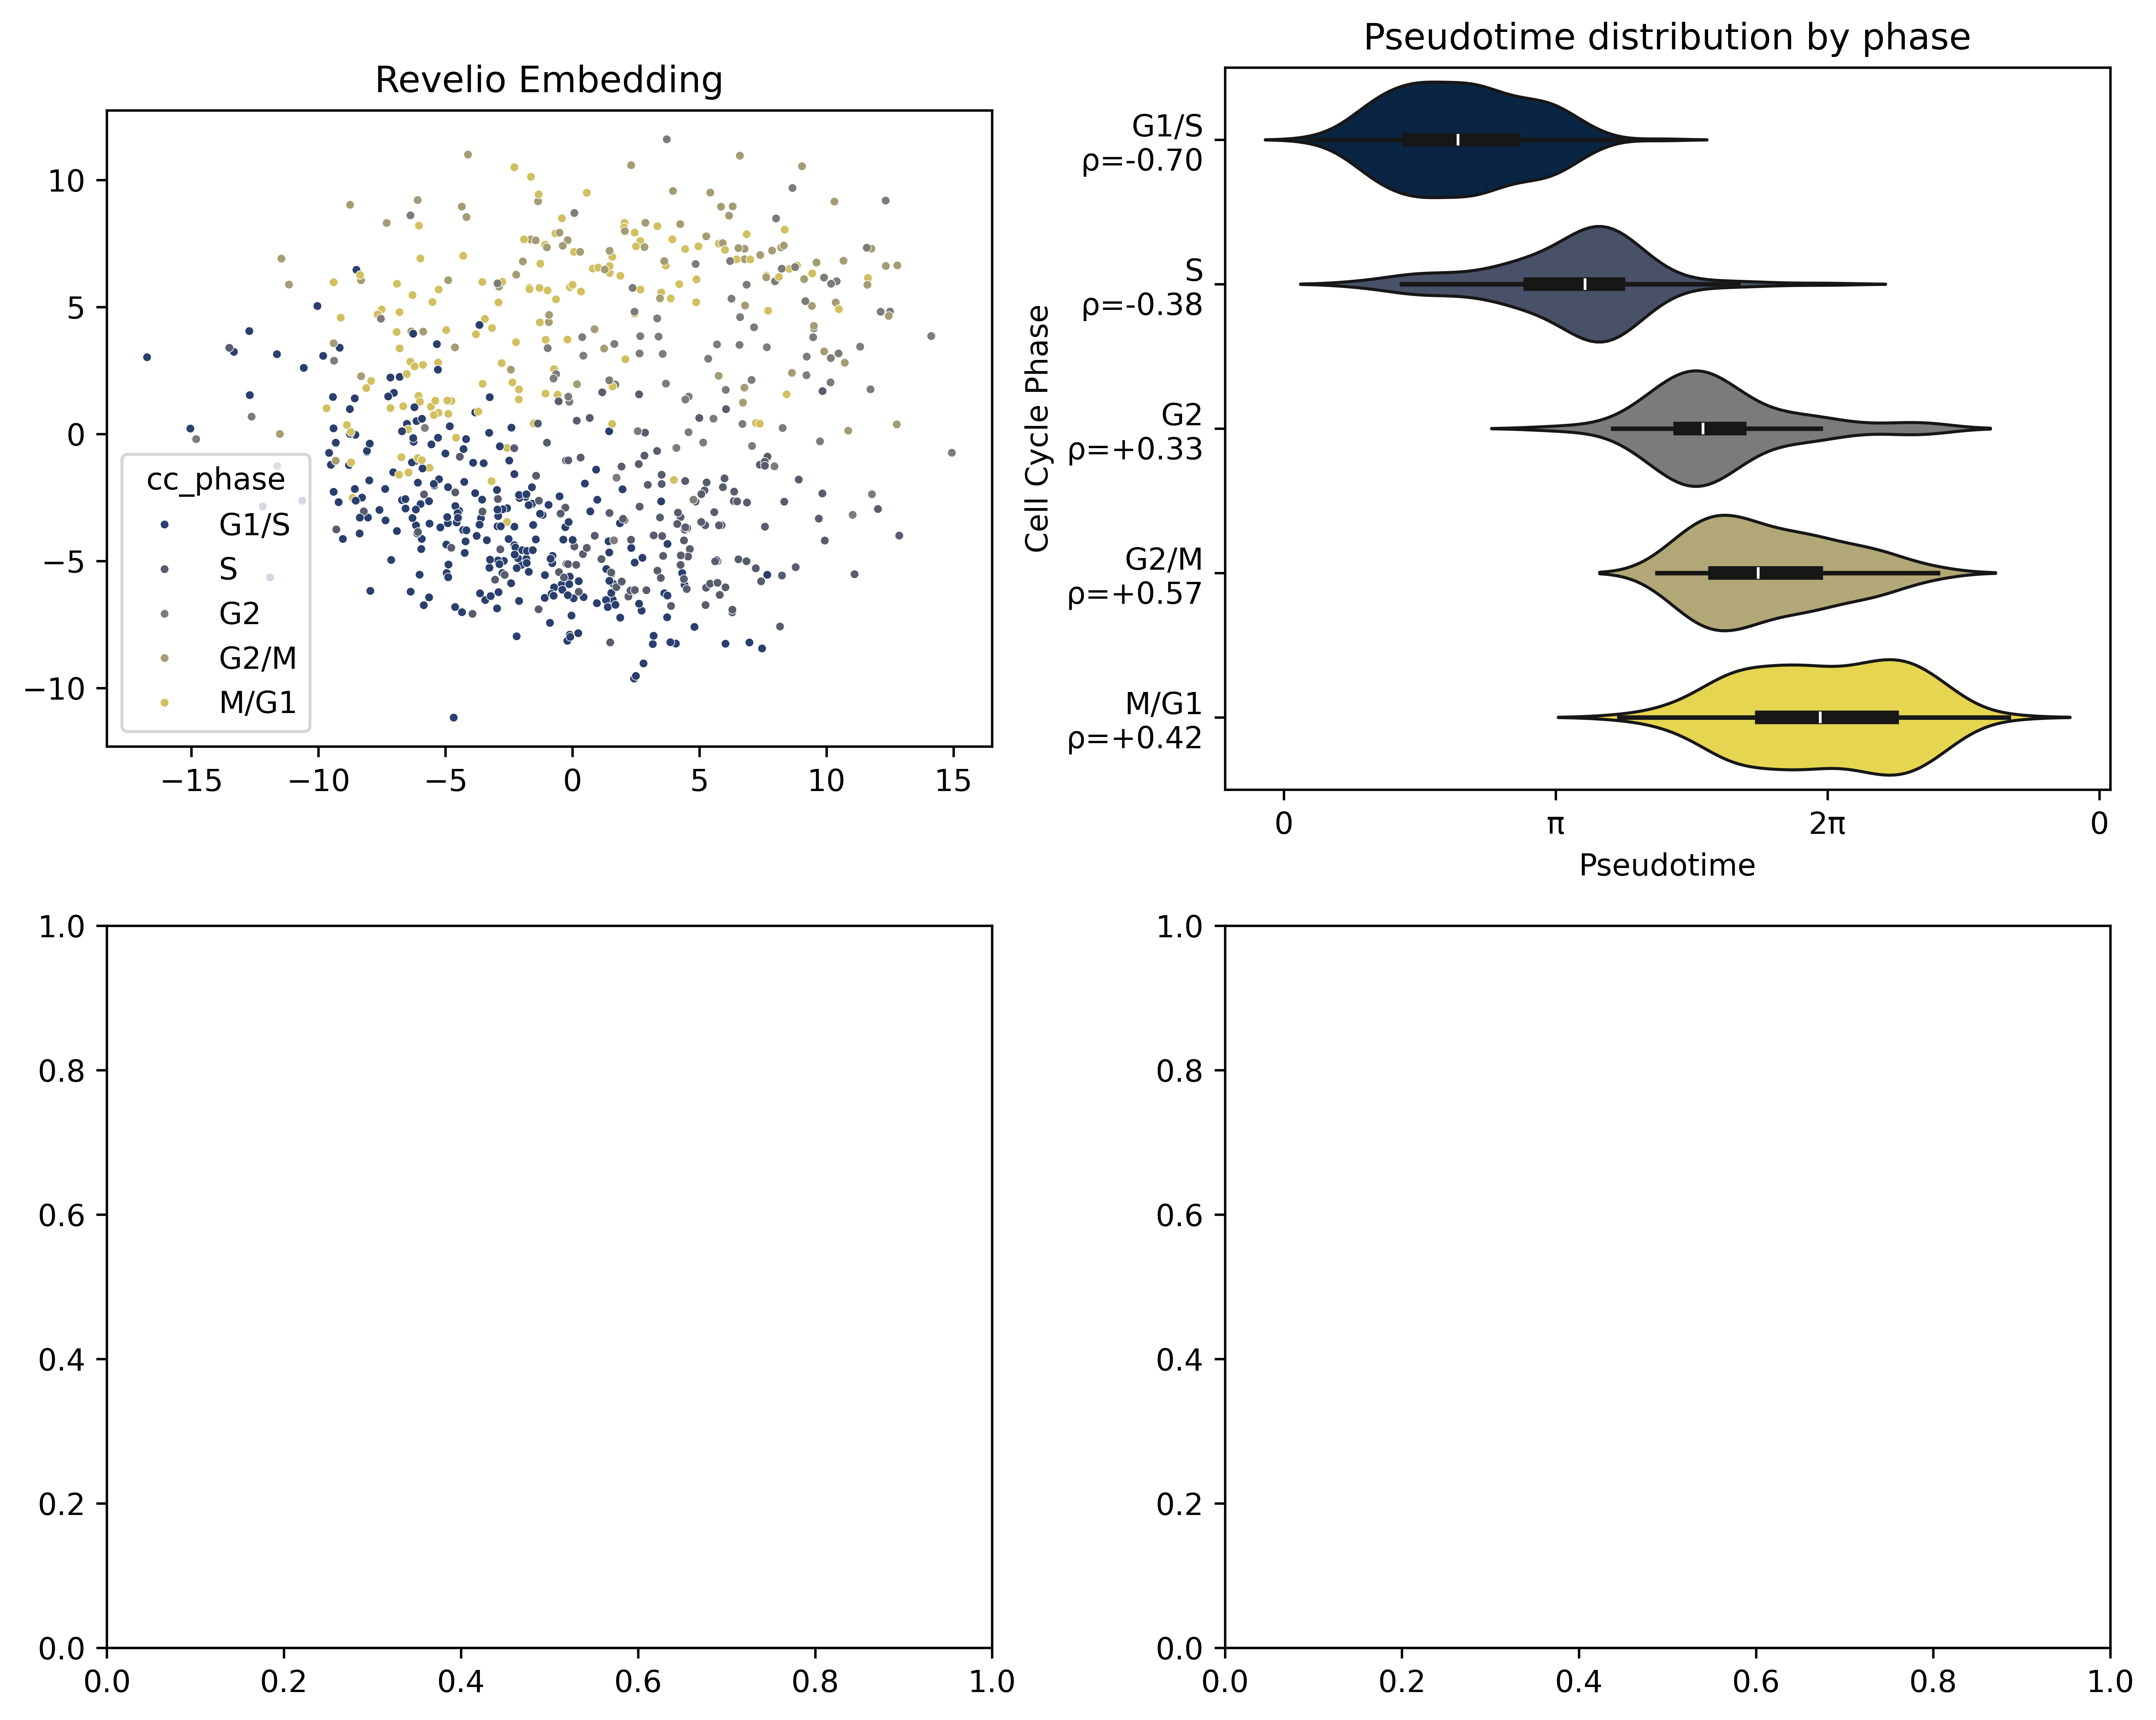

In [18]:
fig,axes = plt.subplots(2,2, figsize=(10,8),dpi=600)
rotated = results['rotated_scores']
rotated = rotated-rotated.mean(axis=0)
adata.obs['pseudotime'] = -np.arctan2(rotated[:,0],rotated[:,1])+np.pi
ax = axes.flat[0]
sns.scatterplot(x=rotated[:,0],y=rotated[:,1],hue=adata.obs['cc_phase'],ax=ax,palette='cividis',s=8)
ax.set_title('Revelio Embedding')
ax.set_aspect('equal')

ax = axes.flat[1]
plot_pseudotime_violin(adata,adata.obs['rvpt'],ax=axes.flat[1])
fig.tight_layout()

